# 02 — Features das músicas

**O que vamos olhar e por quê.** Cada música no MGD+ vem com 9 features acústicas (Spotify Audio Features) + metadata (gênero, artista, duração, ano, etc.). No grafo, são essas as features do nó `music`. Vale ver: as distribuições são razoáveis? alguma feature é "lixo" (constante, vazia)? alguma correlaciona forte com popularidade?

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "exploration":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from music_diffusion_gnn.data.loaders import load_songs

songs = load_songs()
print('shape:', songs.shape)
print('colunas:', list(songs.columns))
songs.head(2)

shape: (5010, 25)
colunas: ['song_id', 'song_name', 'popularity', 'explicit', 'track_number', 'num_available_markets', 'duration_ms', 'artist_id', 'artist_name', 'num_artists', 'song_type', 'release_date', 'key', 'mode', 'time_signature', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'valence', 'tempo', 'total_streams']


,song_id,song_name,popularity,explicit,track_number,num_available_markets,duration_ms,artist_id,artist_name,num_artists,...,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo,total_streams
0,2s2VEFLBcXXox80nSQ91FH,Pimenta,31,False,1,184,160789,['0IpLJsvZHA1op1pw8GAoPu'],['Valesca Popozuda'],1,...,0.224,0.819,0.837,0.000000,0.344,-3.391,0.042,0.775,130.068,42822
1,4MFJja8C5DQGWstBew2BUC,Coastline,0,False,1,0,182520,"['3DnNQH13SfSOjZDsVEa0ht', '7IAFAOtc9kTYNTizhL...","['Liu', 'Hollow Coves', 'WOAK']",3,...,0.265,0.686,0.817,0.000186,0.415,-6.035,0.046,0.474,121.996,107900


In [2]:
# Cobertura: quantos NaN por coluna?
missing = songs.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(2).to_frame('% missing')

,% missing
song_name,0.18
energy,0.02
instrumentalness,0.02
liveness,0.02
danceability,0.02
mode,0.02
time_signature,0.02
acousticness,0.02
key,0.02
speechiness,0.02


## 1) Distribuições das features acústicas

As 9 features clássicas: `acousticness`, `danceability`, `energy`, `instrumentalness`, `liveness`, `loudness`, `speechiness`, `valence`, `tempo`. Todas em [0, 1] exceto `loudness` (dB) e `tempo` (BPM).

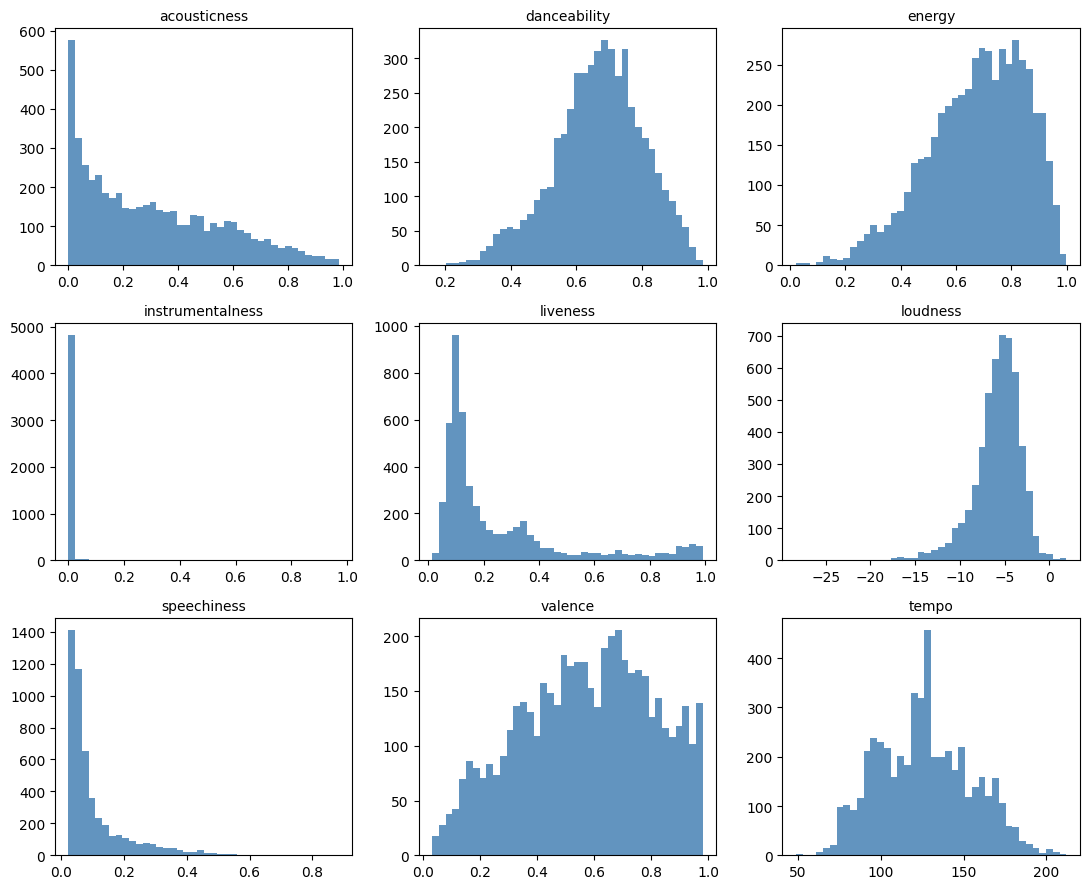

In [3]:
ACOUSTIC = ['acousticness', 'danceability', 'energy', 'instrumentalness',
            'liveness', 'loudness', 'speechiness', 'valence', 'tempo']
ACOUSTIC = [c for c in ACOUSTIC if c in songs.columns]

fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for ax, feat in zip(axes.flat, ACOUSTIC):
    songs[feat].dropna().plot.hist(bins=40, ax=ax, color='steelblue', alpha=0.85)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel('')
plt.tight_layout(); plt.show()

**Leitura típica:** `instrumentalness` e `speechiness` ficam concentradas perto de zero (poucas músicas instrumentais ou faladas no Top 200 BR). `danceability` e `energy` são altas (era pop/funk). `loudness` ~ -7 a -5 dB. `tempo` distribui em torno de 90-130 BPM.

## 2) Correlação features ↔ popularidade

Duas métricas de "popularidade" disponíveis no songs: `popularity` (Spotify, 0-100, snapshot) e `total_streams` (acumulado durante o período, MGD+). A pergunta é: alguma feature tem sinal preditivo direto?

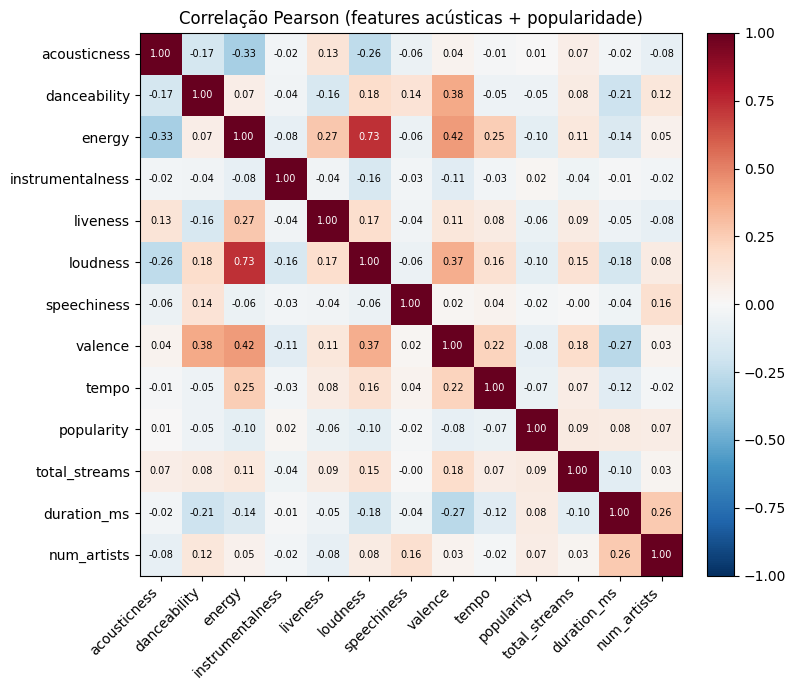

In [4]:
extra = [c for c in ['popularity', 'total_streams', 'duration_ms', 'num_artists'] if c in songs.columns]
corr = songs[ACOUSTIC + extra].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black')
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Correlação Pearson (features acústicas + popularidade)')
plt.tight_layout(); plt.show()

**Leitura:** se as correlações com `popularity` / `total_streams` ficarem fracas (|r| < 0.2), é sinal de que features acústicas isoladas **não explicam popularidade** — o que reforça a tese da tese: o sinal está no entorno (artista, gênero, vizinhança), não dentro da música. Isso é uma boa motivação narrativa para o paper.

## 3) Metadata: gênero, ano, colaboração, explícito

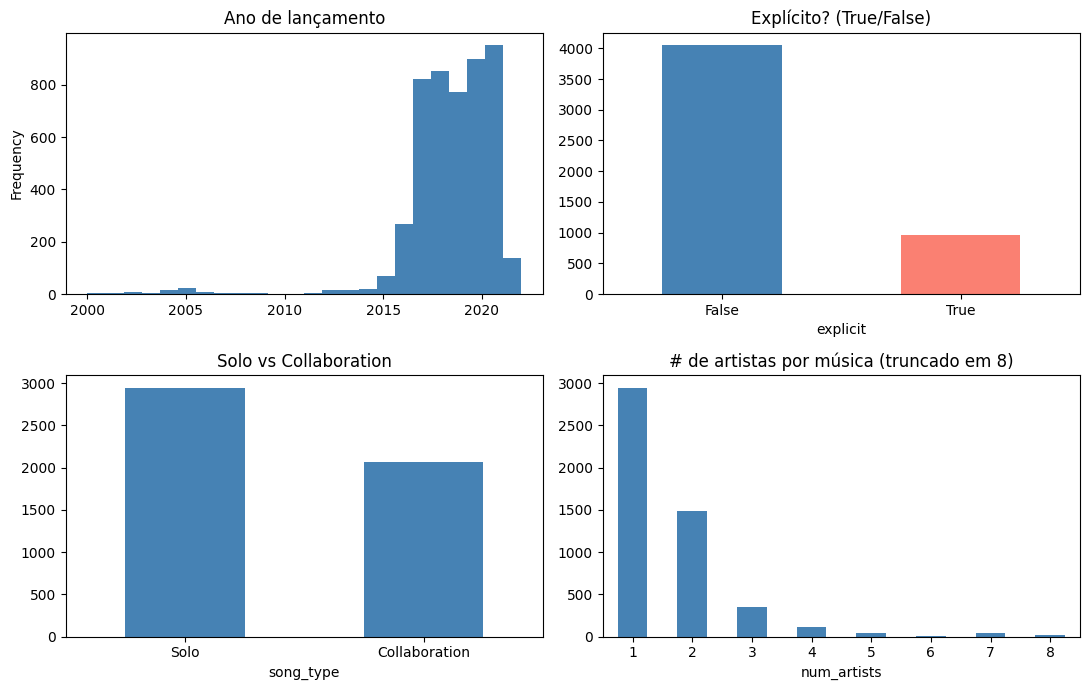

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# (a) ano de lançamento
if 'release_date' in songs.columns:
    years = pd.to_datetime(songs['release_date'], errors='coerce').dt.year
    years[years.between(2000, 2023)].plot.hist(bins=24, ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Ano de lançamento')

# (b) explicit
if 'explicit' in songs.columns:
    songs['explicit'].value_counts().plot.bar(ax=axes[0, 1], color=['steelblue', 'salmon'])
    axes[0, 1].set_title('Explícito? (True/False)')
    axes[0, 1].tick_params(axis='x', rotation=0)

# (c) song_type (Solo / Collaboration)
if 'song_type' in songs.columns:
    songs['song_type'].value_counts().plot.bar(ax=axes[1, 0], color='steelblue')
    axes[1, 0].set_title('Solo vs Collaboration')
    axes[1, 0].tick_params(axis='x', rotation=0)

# (d) número de artistas
if 'num_artists' in songs.columns:
    songs['num_artists'].clip(upper=8).value_counts().sort_index().plot.bar(ax=axes[1, 1], color='steelblue')
    axes[1, 1].set_title('# de artistas por música (truncado em 8)')
    axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

**Leitura:** `song_type` é informação direta para o grafo — toda música rotulada "Collaboration" ativa a aresta `artist↔artist` (collaborates_with). A distribuição por ano mostra se o catálogo é novo (2018+) ou tem cauda de clássicos.

## Insight para o GNN

1. **Features de nó `music`:** as 9 acústicas continuas + `duration_ms` (normalizada) + `num_artists` (1-hot ou contínua) + `explicit` (binária) + embedding de `release_year`. Tudo isso são atributos estáticos do nó.
2. **Features de baixo poder preditivo isolado** (acústicas vs popularidade) **são a justificativa para o GNN**: o sinal estrutural (vizinhança de artistas/gêneros) precisa entrar para tirar o modelo do platô.
3. **`song_type == Collaboration`** indica diretamente quando ativar a aresta `artist→music` para múltiplos artistas (lista em `artist_id`). Não é só um booleano — é a porta de entrada do grafo de colaboração no nível da música.
4. **Features categóricas** (key, mode, time_signature) podem virar embeddings pequenos; valor preditivo provável baixo, mas custa pouco testar.
5. **Cuidado com `popularity` (Spotify):** é snapshot atual, **vaza informação do futuro** se usado como feature. Manter só como referência exploratória, nunca como input do modelo.